In [7]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np

from portfolio_optimizer.data_loader import (
    download_prices,
    compute_returns
)

from portfolio_optimizer.optimization import (
    baseline_lp,
    risk_constrained_lp,
    milp_rebalancing
)

from portfolio_optimizer.plots import plot_weights

[*********************100%***********************]  8 of 8 completed


  Asset  Weight
0   SPY    0.00
1   QQQ    0.35
2  MAIN    0.00
3     O    0.35
4  SCHD    0.00
5   VEA    0.00
6   VWO    0.30
7   BND    0.00
Expected Portfolio Return: 0.1954


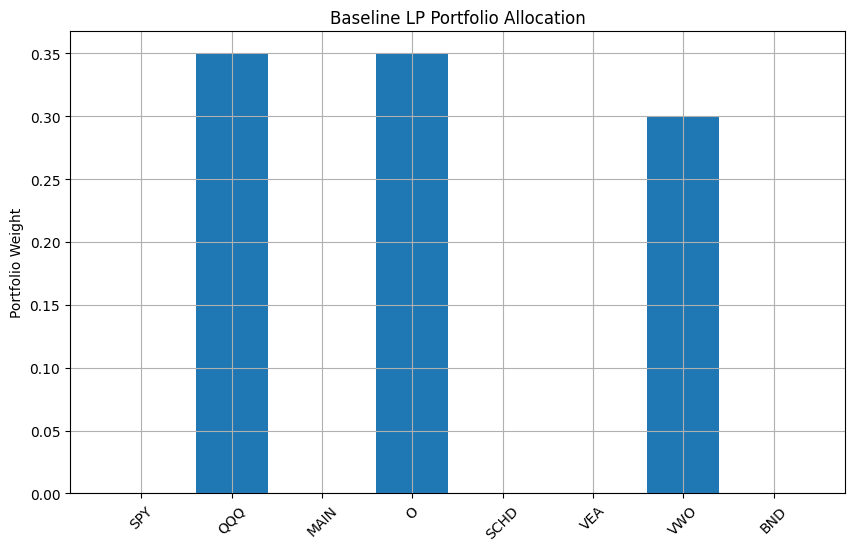

  Asset  Weight
0   SPY  0.0000
1   QQQ  0.3500
2  MAIN  0.0000
3     O  0.1279
4  SCHD  0.0000
5   VEA  0.0000
6   VWO  0.3500
7   BND  0.1721


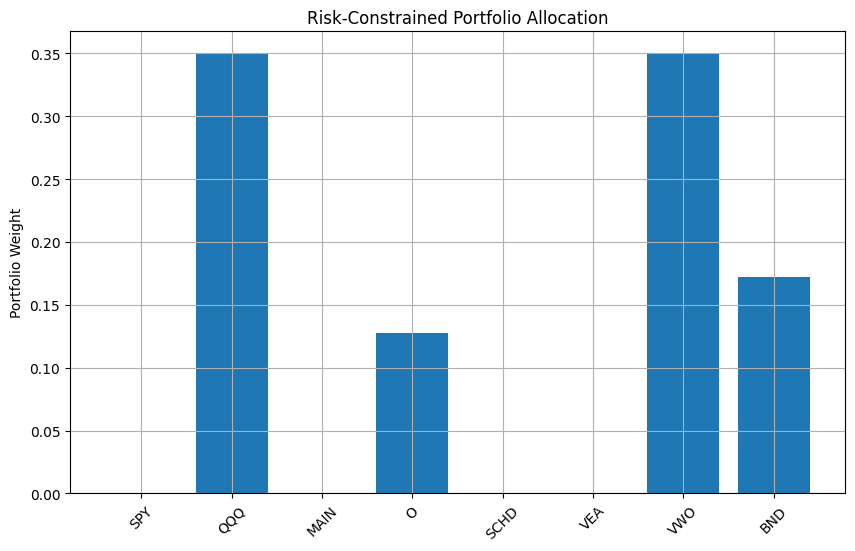

,Asset,NewWeight,Buy,Sell,Traded
0,SPY,0.000,0.000,0.125,1.0
1,QQQ,0.350,0.225,0.000,1.0
2,MAIN,0.125,0.000,0.000,0.0
3,O,0.150,0.025,0.000,1.0
4,SCHD,0.000,0.000,0.125,1.0
5,VEA,0.125,0.000,0.000,0.0
6,VWO,0.125,0.000,0.000,0.0
7,BND,0.125,0.000,0.000,0.0


In [8]:
tickers = ["SPY", "QQQ", "MAIN", "O", "SCHD", "VEA", "VWO", "BND"]

prices = download_prices(
    tickers,
    "2024-03-11",
    "2026-03-11"
)

returns, mean_returns, risk = compute_returns(prices)

weights, portfolio_return = baseline_lp(mean_returns)

weights_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": weights
})

weights_df["Weight"] = weights_df["Weight"].round(4)

print(weights_df)

print(f"Expected Portfolio Return: {portfolio_return:.4f}")

plot_weights(
    weights,
    tickers,
    "Baseline LP Portfolio Allocation"
)

risk_weights, risk_return, risk_value = risk_constrained_lp(
    mean_returns,
    risk
)

risk_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": risk_weights
})

risk_df["Weight"] = risk_df["Weight"].round(4)

print(risk_df)

plot_weights(
    risk_weights,
    tickers,
    "Risk-Constrained Portfolio Allocation"
)

current_weights = pd.Series(
    np.ones(len(tickers)) / len(tickers),
    index=tickers
)

(
    milp_weights,
    buys,
    sells,
    traded,
    milp_return
) = milp_rebalancing(
    mean_returns,
    current_weights
)

milp_df = pd.DataFrame({
    "Asset": tickers,
    "NewWeight": milp_weights,
    "Buy": buys,
    "Sell": sells,
    "Traded": traded
})

milp_df.round(4)